In [12]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
import matplotlib.pyplot as plt

In [13]:
# Cell 2: Locate dataset
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/adrianmcmahon/imdb-india-movies/IMDb Movies India.csv


In [14]:
# Cell 3: Load dataset
df = pd.read_csv(
    "/kaggle/input/datasets/adrianmcmahon/imdb-india-movies/IMDb Movies India.csv",
    encoding='latin1'
)

print(df.head())
print(df.shape)
print(df.columns.tolist())
df.info()

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [15]:
# Cell 4: Drop rows only where the TARGET is missing (don't nuke the whole dataset)
df = df.dropna(subset=['Rating']).copy()
print(df.shape)

(7919, 10)


In [5]:
#clean and check
df.dropna(inplace=True)
print(df.shape)

(5659, 10)


In [16]:
# Cell 5: Clean numeric-looking columns that are stored as text
# Year often looks like "(2019)" -> strip non-digits
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})').astype(float)

# Duration often looks like "109 min" -> strip "min"
df['Duration'] = df['Duration'].astype(str).str.extract(r'(\d+)').astype(float)

# Votes often looks like "1,086" -> strip commas
df['Votes'] = (
    df['Votes'].astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)')
    .astype(float)
)

print(df[['Year', 'Duration', 'Votes']].dtypes)
print(df[['Year', 'Duration', 'Votes']].isnull().sum())

Year        float64
Duration    float64
Votes       float64
dtype: object
Year           0
Duration    2068
Votes          0
dtype: int64


In [17]:
# Cell 7: Genre is multi-label (e.g. "Drama, Musical") - split and one-hot encode
genre_dummies = df['Genre'].str.get_dummies(sep=', ')
genre_dummies.columns = ['Genre_' + g.strip() for g in genre_dummies.columns]

print(genre_dummies.shape)
print(genre_dummies.columns.tolist()[:10])

(7919, 22)
['Genre_Action', 'Genre_Adventure', 'Genre_Animation', 'Genre_Biography', 'Genre_Comedy', 'Genre_Crime', 'Genre_Documentary', 'Genre_Drama', 'Genre_Family', 'Genre_Fantasy']


In [18]:
# Cell 8: Assemble feature matrix and target BEFORE encoding high-cardinality columns
df = pd.concat([df.reset_index(drop=True), genre_dummies.reset_index(drop=True)], axis=1)

feature_cols = ['Year', 'Duration', 'Votes'] + list(genre_dummies.columns) + \
                ['Director', 'Actor 1', 'Actor 2', 'Actor 3']

X = df[feature_cols].copy()
y = df['Rating']

print(X.shape, y.shape)

(7919, 29) (7919,)


In [9]:
X = df[['Year','Duration','Votes','Genre',
        'Director','Actor 1','Actor 2','Actor 3']]

y = df['Rating']
print(df.columns.tolist())

['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [19]:
# Cell 9: Train/test split BEFORE fitting any encoders (avoid leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(6335, 29) (1584, 29)


In [20]:
# Cell 10: Frequency-encode high-cardinality columns (Director, Actor 1/2/3)
# Fit frequency maps on TRAIN ONLY, then apply to test (avoids leakage,
# and avoids the fake ordinal relationships LabelEncoder would introduce)
high_card_cols = ['Director', 'Actor 1', 'Actor 2', 'Actor 3']
freq_maps = {}

for col in high_card_cols:
    freq_maps[col] = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(freq_maps[col]).fillna(0)
    X_test[col] = X_test[col].map(freq_maps[col]).fillna(0)  # unseen names -> 0

print(X_train[high_card_cols].head())

      Director   Actor 1   Actor 2   Actor 3
4252  0.000316  0.000321  0.000162  0.000164
4428  0.004739  0.011865  0.000810  0.003444
7373  0.000948  0.006253  0.000648  0.003444
1410  0.000316  0.000481  0.008096  0.001476
7895  0.000316  0.004810  0.003238  0.000164


In [21]:
# Cell 11: Baseline model - always predict the mean rating
# This gives us something real to compare the Random Forest against
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R2  :", baseline_r2)

Baseline MAE : 1.1072005074422202
Baseline RMSE: 1.364534778211662
Baseline R2  : -0.0015114582746571514


In [22]:
# Cell 12: Train Random Forest with cross-validation (more stable than one split)
model = RandomForestRegressor(n_estimators=200, random_state=42)

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print("CV R2 scores:", cv_scores)
print("CV R2 mean  :", cv_scores.mean(), "(+/-", cv_scores.std(), ")")

model.fit(X_train, y_train)
print("Model Trained Successfully!")

CV R2 scores: [0.3473153  0.36828047 0.3948881  0.37523138 0.36391132]
CV R2 mean  : 0.36992531324005934 (+/- 0.01550084657594521 )
Model Trained Successfully!


In [23]:
# Cell 13: Make predictions
y_pred = model.predict(X_test)
print(y_pred[:10])

[4.58   5.4185 4.999  5.1345 5.8955 5.916  5.8045 6.9655 5.817  6.18  ]


In [24]:
# Cell 14: Evaluate model and compare against baseline
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest MAE :", mae)
print("Random Forest RMSE:", rmse)
print("Random Forest R2  :", r2)
print()
print(f"Improvement over baseline R2: {r2 - baseline_r2:.4f}")

Random Forest MAE : 0.825195838594276
Random Forest RMSE: 1.0955742048258144
Random Forest R2  : 0.3543899225291859

Improvement over baseline R2: 0.3559


In [25]:
# Cell 15: Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

              Feature  Importance
2               Votes    0.236748
0                Year    0.214570
1            Duration    0.112763
26            Actor 1    0.064360
25           Director    0.060454
27            Actor 2    0.059857
28            Actor 3    0.059234
9   Genre_Documentary    0.037307
3        Genre_Action    0.022137
10        Genre_Drama    0.021201
19      Genre_Romance    0.016865
14       Genre_Horror    0.016387
7        Genre_Comedy    0.014333
22     Genre_Thriller    0.011010
8         Genre_Crime    0.009894
16      Genre_Musical    0.006314
11       Genre_Family    0.005997
4     Genre_Adventure    0.005857
17      Genre_Mystery    0.004927
12      Genre_Fantasy    0.003702
13      Genre_History    0.003473
6     Genre_Biography    0.003265
20       Genre_Sci-Fi    0.002185
23          Genre_War    0.001932
15        Genre_Music    0.001831
5     Genre_Animation    0.001741
21        Genre_Sport    0.001545
24      Genre_Western    0.000104
18         Gen

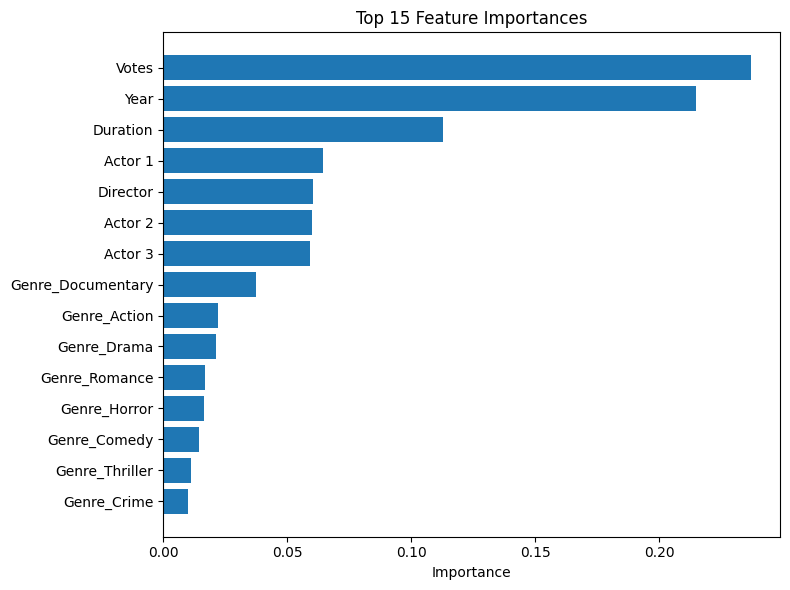

In [27]:
# Cell 16: Visualization - feature importance
plt.figure(figsize=(8, 6))
plt.barh(importance['Feature'].head(15), importance['Importance'].head(15))
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

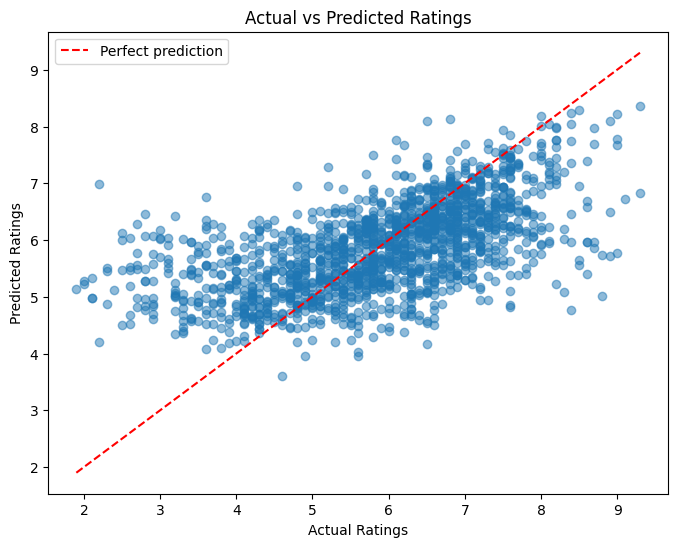

In [28]:
# Cell 17: Visualization - Actual vs Predicted, with a perfect-prediction reference line
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Diagonal reference line: predictions falling on it are perfect
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.legend()
plt.show()